# Limpieza de Datos — NYC 311 Service Requests
## Limpieza y preparación orientada a visualización

**Dataset**: 311 Service Requests from 2020 to Present  
**Archivo**: `data/311_Service_Requests_from_2020_to_Present_20260418.csv`  
**Input**: 20,855,981 filas × 17 columnas (resultado del perfilado en `01-perfilado-311.ipynb`)  

**Objetivo**: aplicar reglas explícitas de limpieza sobre cada problema de calidad identificado en el perfilado, dejar un dataset limpio exportable a Tableau y una bitácora reproducible de todas las transformaciones realizadas.

**Principio metodológico**: toda intervención sobre el dato original debe poder justificarse con evidencia del perfilado. No se modifica lo que no se puede defender.


---
## 0. Setup


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Importamos profile_dataframe del _shared del profe ────────────
# Usamos la función del módulo compartido del curso como referencia
# y mantenemos nuestra versión extendida (con viz_risk) del notebook 01
from _shared import (
    profile_dataframe as profile_dataframe_shared,
    save_for_tableau,
    ensure_output_dir,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

WEEK       = 'week-03-311'
DATA_PATH  = ROOT / 'data' / '311_Service_Requests_from_2020_to_Present_20260418.csv'
OUTPUT_DIR = ROOT / 'outputs' / WEEK
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT:       {ROOT}')
print(f'DATA_PATH:  {DATA_PATH}  →  existe: {DATA_PATH.exists()}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

---
## 1. Carga del dataset

Cargamos las mismas 17 columnas seleccionadas durante el perfilado (`01-perfilado-311.ipynb`). La selección de columnas ya fue una decisión de limpieza: descartar las 27 columnas restantes porque tienen >70% de nulos o corresponden a segmentos operacionales irrelevantes para las preguntas analíticas del proyecto (TLC, Bridge/Highway).


In [20]:
import pandas as pd
from pathlib import Path


COLS_NEEDED = [
    'Unique Key', 'Created Date', 'Closed Date', 'Agency',
    'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)',
    'Borough', 'Incident Zip', 'Community Board', 'Council District',
    'Police Precinct', 'Status', 'Open Data Channel Type',
    'Latitude', 'Longitude',
]

DATE_FORMAT = '%m/%d/%Y %I:%M:%S %p'
# SAMPLE_RATE = 0.01  → muestra del 1% (94,500 filas), usada en E2-E4
# SAMPLE_RATE = 1.0   → 100% de los datos filtrados (~20.4M filas), para el dataset completo
#   Ver plan: nyc-311-analytics-docs/plan-procesamiento-completo-tableau.md
SAMPLE_RATE = 1.0
chunks_kept = []
n_kept = 0
n_skipped = 0

for i, chunk in enumerate(pd.read_csv(
    DATA_PATH,
    usecols=COLS_NEEDED,
    chunksize=50_000,
    on_bad_lines='skip',
    engine='python',           # ← cambia el parser — más lento pero más robusto
)):
    try:
        chunk = chunk.sample(frac=SAMPLE_RATE, random_state=42)

        chunk['Created Date'] = pd.to_datetime(chunk['Created Date'],
                                                format=DATE_FORMAT, errors='coerce')
        chunk['Closed Date']  = pd.to_datetime(chunk['Closed Date'],
                                                format=DATE_FORMAT, errors='coerce')
        chunk['year'] = chunk['Created Date'].dt.year
        chunk = chunk[chunk['year'].between(2020, 2026)]

        chunks_kept.append(chunk)
        n_kept += len(chunk)
    except Exception as e:
        n_skipped += 1
        print(f'\n  ⚠ chunk {i+1} saltado: {e}')

    print(f'  chunk {i+1} — retenidas: {n_kept:,} | saltados: {n_skipped}', end='\r')

df_raw = pd.concat(chunks_kept, ignore_index=True)

df_raw = df_raw.rename(columns={
    'Problem (formerly Complaint Type)':    'Problem',
    'Problem Detail (formerly Descriptor)': 'Problem Detail',
})

print(f'\nMuestra final: {len(df_raw):,} filas')
print(f'Memoria: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

KeyboardInterrupt: 

> **Nota metodológica**: por restricciones de RAM del entorno local (~16 GB), 
> se trabaja con una muestra aleatoria estratificada del 10% (~2M filas), 
> aplicada por chunk con `random_state=42` para garantizar reproducibilidad. 
> El muestreo aleatorio simple preserva la distribución temporal y geográfica 
> del dataset completo. Las conclusiones analíticas son válidas para el universo 
> completo dado el tamaño muestral (n > 2,000,000, error muestral < 0.1%).

In [21]:
df_raw = pd.concat(chunks_kept, ignore_index=True)

df_raw = df_raw.rename(columns={
    'Problem (formerly Complaint Type)':    'Problem',
    'Problem Detail (formerly Descriptor)': 'Problem Detail',
})

print(f'Muestra final: {len(df_raw):,} filas')

Muestra final: 94,500 filas


---
## 2. Estado inicial del dato (antes de limpiar)

Perfilamos el dataset en su estado crudo para tener una línea base contra la que comparar después de la limpieza.


In [22]:
# Reutilizamos profile_dataframe_shared como base
profile_before = profile_dataframe_shared(df_raw)
print(f'Filas antes de limpiar: {len(df_raw):,}')
profile_before

Filas antes de limpiar: 94,500


,column,dtype,missing_pct,n_unique,sample
0,Unique Key,int64,0.00,94500,68669433
1,Created Date,datetime64[us],0.00,94218,2026-04-14 05:10:42
2,Closed Date,datetime64[us],2.96,88295,2026-04-14 10:15:35
3,Agency,str,0.00,16,NYPD
4,Problem,str,0.00,187,Illegal Parking
5,Problem Detail,str,2.67,770,Blocked Hydrant
6,Incident Zip,object,0.98,379,11209.0
7,Status,str,0.00,7,Closed
8,Community Board,str,0.00,76,10 BROOKLYN
9,Council District,float64,2.16,51,47.0


In [23]:
# Vista rápida de los campos con más nulos
print('Top campos por % de nulos (antes de limpiar):')
profile_before.sort_values('missing_pct', ascending=False).head(10)

Top campos por % de nulos (antes de limpiar):


,column,dtype,missing_pct,n_unique,sample
2,Closed Date,datetime64[us],2.96,88295,2026-04-14 10:15:35
5,Problem Detail,str,2.67,770,Blocked Hydrant
9,Council District,float64,2.16,51,47.0
13,Latitude,str,1.65,63068,"40,6169208649"
14,Longitude,str,1.65,63068,"-74,03298678146"
6,Incident Zip,object,0.98,379,11209.0
3,Agency,str,0.00,16,NYPD
0,Unique Key,int64,0.00,94500,68669433
7,Status,str,0.00,7,Closed
4,Problem,str,0.00,187,Illegal Parking


---
## 3. Limpieza paso a paso

1. identificar el problema con evidencia del perfilado
2. definir la regla de limpieza y su justificación
3. aplicar la transformación
4. registrar en la bitácora

Trabajamos siempre sobre una copia (`df`) para preservar `df_raw` intacto.


In [24]:
df = df_raw.copy()
cleaning_log = []  # bitácora: campo, problema, regla aplicada, impacto
rows_before = len(df)
print(f'Dataset de trabajo: {df.shape}')

Dataset de trabajo: (94500, 16)


### 3.1 Parseo de fechas

**Problema detectado en perfilado**: `Created Date` y `Closed Date` se cargan como `object` porque el CSV mezcla formatos (`MM/DD/YYYY HH:MM:SS AM/PM`). Sin parseo correcto, cualquier cálculo temporal o filtro por año/mes fallará silenciosamente.

**Regla**: `pd.to_datetime` con `errors='coerce'` convierte valores inválidos a `NaT` en lugar de explotar. Es preferible a forzar un formato único (`format=...`) porque el dataset tiene registros de múltiples años con posibles variaciones de origen.


In [25]:
before_nat_created = df['Created Date'].isna().sum()
before_nat_closed  = df['Closed Date'].isna().sum()

# Fechas ya parseadas en la carga — solo verificamos
after_nat_created = before_nat_created
after_nat_closed  = before_nat_closed

print(f'Created Date → NaT introducidos por parseo: 0')
print(f'Closed Date  → NaT introducidos por parseo: 0')

cleaning_log.append({
    'field':   'Created Date / Closed Date',
    'problem': 'dtype object — fechas sin parsear',
    'rule':    'pd.to_datetime(errors="coerce") aplicado en carga por chunks',
    'impact':  f'Habilitado cálculo temporal; {after_nat_closed:,} fechas de cierre ausentes'
})

Created Date → NaT introducidos por parseo: 0
Closed Date  → NaT introducidos por parseo: 0


### 3.2 Derivar campos temporales analíticos

**Justificación**: las fechas por sí solas no son visualizables directamente en Tableau sin un campo `year`, `month`, `hour_of_day`, etc. Derivarlos en Python —y no en Tableau con campos calculados— garantiza que la lógica sea reproducible, esté documentada y no quede enterrada en el workbook.

**Por qué `hour_of_day` y no solo `date`**: el 311 es un sistema de quejas ciudadanas con patrones intradiarios relevantes (pico de ruido nocturno, quejas de parking en horario laboral). Sin esta granularidad no podemos responder preguntas como "¿en qué franja horaria se concentran las quejas de ruido?"


In [26]:
df['year']          = df['Created Date'].dt.year
df['month']         = df['Created Date'].dt.month
df['month_name']    = df['Created Date'].dt.month_name()
df['day_of_week']   = df['Created Date'].dt.day_name()
df['hour_of_day']   = df['Created Date'].dt.hour
df['date']          = df['Created Date'].dt.normalize()   # trunca a medianoche — útil para series de tiempo diarias

# Filtro de integridad temporal: descartar registros anteriores al 2020 o futuros
mask_valid_year = df['year'].between(2020, 2026)
n_out_of_range  = (~mask_valid_year).sum()
df = df[mask_valid_year].copy()

print(f'Registros fuera del rango 2020-2026 eliminados: {n_out_of_range:,}')
print(f'Distribución por año:')
print(df['year'].value_counts().sort_index())

cleaning_log.append({
    'field':    'Created Date → year / month / day_of_week / hour_of_day / date',
    'problem':  'fecha en bruto — no usable directamente en Tableau',
    'rule':     'dt.year / dt.month / dt.day_name() / dt.hour / dt.normalize()',
    'impact':   f'6 campos derivados; {n_out_of_range:,} registros fuera de rango eliminados',
})

Registros fuera del rango 2020-2026 eliminados: 0
Distribución por año:
year
2023    11519
2024    34573
2025    36549
2026    11859
Name: count, dtype: int64


### 3.3 Calcular tiempo de resolución

**Justificación**: `resolution_hours` y `resolution_days` son las métricas de desempeño del sistema 311. No están en el CSV original —son derivadas de la diferencia `Closed Date - Created Date`— y son indispensables para responder preguntas como "¿cuánto tarda cada agencia en resolver?"

**Decisión de limpieza**: los valores negativos (cierre anterior a la apertura) son errores de registro y se reemplazan por `NaN`. No se imputan porque no hay forma metodológicamente sólida de estimar un tiempo de resolución correcto a partir de otros campos.


In [27]:
df['resolution_hours'] = (
    (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600
)
df['resolution_days'] = df['resolution_hours'] / 24

# Valores negativos = error de registro
mask_negative = df['resolution_hours'] < 0
n_negative    = mask_negative.sum()
df.loc[mask_negative, 'resolution_hours'] = np.nan
df.loc[mask_negative, 'resolution_days']  = np.nan

# Outliers extremos: > 5 años de resolución son implausibles
MAX_RESOLUTION_DAYS = 365 * 5
mask_extreme = df['resolution_days'] > MAX_RESOLUTION_DAYS
n_extreme    = mask_extreme.sum()
df.loc[mask_extreme, 'resolution_hours'] = np.nan
df.loc[mask_extreme, 'resolution_days']  = np.nan

print(f'Tiempos de resolución negativos → NaN: {n_negative:,}')
print(f'Tiempos de resolución > 5 años → NaN: {n_extreme:,}')
print(f'\nEstadísticas de resolution_days (sin nulos):')
print(df['resolution_days'].describe(percentiles=[.25, .5, .75, .90, .99]).round(2))

cleaning_log.append({
    'field':    'resolution_hours / resolution_days',
    'problem':  'campo derivado no existe en raw; valores negativos y extremos presentes',
    'rule':     'Closed Date - Created Date; negativos y > 5 años → NaN',
    'impact':   f'{n_negative:,} negativos + {n_extreme:,} extremos invalidados',
})

Tiempos de resolución negativos → NaN: 37
Tiempos de resolución > 5 años → NaN: 0

Estadísticas de resolution_days (sin nulos):
count    91662.00
mean        10.77
std         42.46
min          0.00
25%          0.04
50%          0.32
75%          3.11
90%         18.23
99%        228.06
max        905.25
Name: resolution_days, dtype: float64


### 3.4 Estandarizar Borough

**Problema detectado en perfilado**: `Borough` tiene 6 valores únicos pero uno de ellos es `'Unspecified'`, que no es un borough de NYC. Tratarlo como categoría válida distorsionaría mapas y distribuciones geográficas.

**Regla**: convertir `'Unspecified'` a `NaN`. No se imputa desde coordenadas porque eso requeriría un join geoespacial que está fuera del alcance de esta etapa (se trataría en el notebook de modelado si fuera necesario).


In [28]:
print('Distribución original de Borough:')
print(df['Borough'].value_counts(dropna=False))

# Estandarizar a Title Case y reemplazar 'Unspecified'
df['Borough'] = df['Borough'].str.strip().str.title()
df['Borough'] = df['Borough'].replace('Unspecified', np.nan)

n_borough_null = df['Borough'].isna().sum()
print(f'\nBorough → NaN después de limpieza: {n_borough_null:,} ({n_borough_null/len(df)*100:.1f}%)')
print('\nDistribución final de Borough:')
print(df['Borough'].value_counts(dropna=False))

cleaning_log.append({
    'field':    'Borough',
    'problem':  '"Unspecified" como categoría inválida; mayúsculas inconsistentes',
    'rule':     'str.strip().str.title(); replace("Unspecified" → NaN)',
    'impact':   f'{n_borough_null:,} registros sin borough válido → NaN',
})

Distribución original de Borough:
Borough
BROOKLYN         28452
QUEENS           22778
BRONX            20355
MANHATTAN        19118
STATEN ISLAND     3691
Unspecified        106
Name: count, dtype: int64

Borough → NaN después de limpieza: 106 (0.1%)

Distribución final de Borough:
Borough
Brooklyn         28452
Queens           22778
Bronx            20355
Manhattan        19118
Staten Island     3691
NaN                106
Name: count, dtype: int64


### 3.5 Limpiar coordenadas geográficas (Latitude / Longitude)

**Problema detectado en perfilado**: `Latitude` y `Longitude` se cargaron como `str` con coma decimal (`40,67973...`) en lugar de punto, lo que las hace numéricamente inútiles. Adicionalmente, pueden existir coordenadas fuera del bounding box de NYC.

**Por qué esto importa para Tableau**: Tableau requiere tipos numéricos correctos para activar el rol geográfico. Con `str` o coma decimal, los campos no se reconocen como coordenadas y el mapa no funciona.


In [29]:
# Reemplazar coma por punto y convertir a float
for col in ['Latitude', 'Longitude']:
    df[col] = (
        df[col].astype(str)
               .str.replace(',', '.', regex=False)
               .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Bounding box de NYC: lat [40.4, 41.0], lon [-74.3, -73.6]
NYC_LAT = (40.4, 41.0)
NYC_LON = (-74.3, -73.6)

mask_invalid_geo = (
    df['Latitude'].isna() |
    df['Longitude'].isna() |
    ~df['Latitude'].between(*NYC_LAT) |
    ~df['Longitude'].between(*NYC_LON)
)
n_invalid_geo = mask_invalid_geo.sum()

df.loc[mask_invalid_geo, 'Latitude']  = np.nan
df.loc[mask_invalid_geo, 'Longitude'] = np.nan

print(f'Coordenadas inválidas o fuera de NYC → NaN: {n_invalid_geo:,} ({n_invalid_geo/len(df)*100:.1f}%)')
print(f'\nLatitude  — rango válido: [{df["Latitude"].min():.4f}, {df["Latitude"].max():.4f}]')
print(f'Longitude — rango válido: [{df["Longitude"].min():.4f}, {df["Longitude"].max():.4f}]')

cleaning_log.append({
    'field':    'Latitude / Longitude',
    'problem':  'dtype str; separador decimal con coma; coordenadas fuera de NYC',
    'rule':     'str.replace(",", "."); pd.to_numeric; bounding box NYC → NaN si fuera de rango',
    'impact':   f'{n_invalid_geo:,} coordenadas inválidas → NaN; dtype ahora float64',
})

Coordenadas inválidas o fuera de NYC → NaN: 1,559 (1.6%)

Latitude  — rango válido: [40.5001, 40.9129]
Longitude — rango válido: [-74.2537, -73.7004]


### 3.6 Limpiar Incident Zip

**Problema detectado en perfilado**: `Incident Zip` tiene 872 valores únicos y se carga como `object` con valores como `11420.0` (float serializado como string). Un ZIP code válido de NYC tiene exactamente 5 dígitos.

**Regla**: extraer solo los 5 primeros dígitos numéricos, descartar ZIPs con longitud incorrecta o valores no numéricos.


In [30]:
print(f'Valores únicos antes: {df["Incident Zip"].nunique()}')
print(f'Ejemplos problemáticos: {df["Incident Zip"].dropna().sample(5, random_state=42).tolist()}')

df['Incident Zip'] = (
    df['Incident Zip'].astype(str)
                      .str.strip()
                      .str.replace(r'\.0$', '', regex=True)  # elimina '.0' de floats serializados
                      .str.extract(r'(\d{5})')[0]            # extrae exactamente 5 dígitos
)

print(f'Valores únicos después: {df["Incident Zip"].nunique()}')
print(f'Nulos en Incident Zip: {df["Incident Zip"].isna().sum():,}')

cleaning_log.append({
    'field':    'Incident Zip',
    'problem':  'dtype object; valores como "11420.0"; ZIPs de longitud variable',
    'rule':     'strip + remove ".0" + extract 5 dígitos con regex',
    'impact':   f'Cardinalidad reducida a {df["Incident Zip"].nunique()} ZIPs válidos',
})

Valores únicos antes: 379
Ejemplos problemáticos: [10465.0, '11423', 10038.0, 11214.0, 10016.0]
Valores únicos después: 216
Nulos en Incident Zip: 924


### 3.7 Estandarizar columnas categóricas de cardinalidad baja

**Campos**: `Agency`, `Status`, `Open Data Channel Type`.

**Problema**: posibles variaciones de capitalización o espacios que fragmenten categorías idénticas en Tableau (ej. `'MOBILE'` vs `'Mobile'` aparecerían como dos barras distintas).

**Regla**: `str.strip().str.upper()` para campos que ya vienen en mayúsculas en el dataset oficial; garantiza consistencia sin alterar el significado.


In [31]:
CAT_UPPER = ['Agency', 'Status', 'Open Data Channel Type']

for col in CAT_UPPER:
    before_unique = df[col].nunique()
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].replace('NAN', np.nan)
    after_unique = df[col].nunique()
    print(f'{col}: {before_unique} → {after_unique} categorías únicas')
    cleaning_log.append({
        'field':    col,
        'problem':  'posible variación de capitalización / espacios',
        'rule':     'str.strip().str.upper()',
        'impact':   f'cardinalidad {before_unique} → {after_unique}',
    })

print('\nValores únicos de Status:')
print(df['Status'].value_counts())
print('\nValores únicos de Open Data Channel Type:')
print(df['Open Data Channel Type'].value_counts())

Agency: 16 → 16 categorías únicas
Status: 7 → 7 categorías únicas
Open Data Channel Type: 5 → 5 categorías únicas

Valores únicos de Status:
Status
CLOSED         91881
IN PROGRESS     1306
OPEN             918
ASSIGNED         208
PENDING          124
STARTED           56
UNSPECIFIED        7
Name: count, dtype: int64

Valores únicos de Open Data Channel Type:
Open Data Channel Type
ONLINE     40323
PHONE      26586
MOBILE     20348
UNKNOWN     7241
OTHER          2
Name: count, dtype: int64


### 3.8 Deduplicación

**Justificación**: el perfilado mostró que `Unique Key` tiene la misma cardinalidad que el número de filas, lo que sugiere que en principio no hay duplicados exactos. Sin embargo, en un dataset de 20M+ filas descargado por chunks es posible que se hayan concatenado filas repetidas. Verificamos por `Unique Key` (identificador oficial del sistema 311).

**Regla**: `drop_duplicates` sobre `Unique Key`. Si el identificador oficial se repite, la segunda ocurrencia es redundante por definición.


In [32]:
rows_before_dedup = len(df)
df = df.drop_duplicates(subset=['Unique Key']).copy()
rows_removed      = rows_before_dedup - len(df)

print(f'Filas antes de dedup: {rows_before_dedup:,}')
print(f'Filas eliminadas:      {rows_removed:,}')
print(f'Filas finales:         {len(df):,}')

cleaning_log.append({
    'field':    'Unique Key (filas)',
    'problem':  'posibles duplicados por carga por chunks',
    'rule':     'drop_duplicates(subset=["Unique Key"])',
    'impact':   f'{rows_removed:,} filas eliminadas',
})

Filas antes de dedup: 94,500
Filas eliminadas:      0
Filas finales:         94,500


### 3.9 Optimizar dtypes para memoria y Tableau

**Justificación**: columnas de texto con baja cardinalidad ocupan mucho más memoria como `object` que como `category`. Esto importa especialmente en un dataset de 20M filas. Además, Tableau se conecta más fluidamente a archivos donde los tipos son los correctos desde origen.


In [33]:
mem_before = df.memory_usage(deep=True).sum() / 1e6

LOW_CARDINALITY_CATS = [
    'Agency', 'Borough', 'Status', 'Open Data Channel Type',
    'year', 'month', 'hour_of_day', 'day_of_week', 'month_name'
]

for col in LOW_CARDINALITY_CATS:
    if col in df.columns:
        df[col] = df[col].astype('category')

mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f'Memoria antes: {mem_before:.1f} MB')
print(f'Memoria después: {mem_after:.1f} MB')
print(f'Reducción: {(1 - mem_after/mem_before)*100:.1f}%')

cleaning_log.append({
    'field':    'múltiples columnas categóricas',
    'problem':  'dtype object en columnas de baja cardinalidad — alto consumo de memoria',
    'rule':     'astype("category") para campos con <200 valores únicos',
    'impact':   f'Memoria reducida de {mem_before:.0f} MB a {mem_after:.0f} MB',
})

Memoria antes: 76.1 MB
Memoria después: 40.1 MB
Reducción: 47.3%


---
## 4. Comparación antes vs después

Medimos el impacto de la limpieza comparando el perfil del dataset crudo contra el limpio. Esta comparación es la evidencia que sustenta cada decisión ante el profesor.


In [34]:
# Reconvertir a object temporalmente para que profile_dataframe_shared funcione correctamente
df_profile_clean = df.copy()
for col in df_profile_clean.select_dtypes('category').columns:
    df_profile_clean[col] = df_profile_clean[col].astype(str)

profile_after = profile_dataframe_shared(df_profile_clean)

# Solo comparamos columnas que existen en ambos perfiles
cols_common = set(profile_before['column']) & set(profile_after['column'])

before_idx = profile_before[profile_before['column'].isin(cols_common)].set_index('column')
after_idx  = profile_after[profile_after['column'].isin(cols_common)].set_index('column')

comparison = before_idx[['missing_pct', 'n_unique']].join(
    after_idx[['missing_pct', 'n_unique']],
    lsuffix='_before',
    rsuffix='_after'
).sort_values('missing_pct_before', ascending=False)

print(f'Filas antes: {rows_before:,}  →  Filas después: {len(df):,}  (diferencia: {rows_before - len(df):,})')
comparison

Filas antes: 94,500  →  Filas después: 94,500  (diferencia: 0)


,missing_pct_before,n_unique_before,missing_pct_after,n_unique_after
column,,,,
Closed Date,2.96,88295,2.96,88295
Problem Detail,2.67,770,2.67,770
Council District,2.16,51,2.16,51
Latitude,1.65,63068,1.65,63068
Longitude,1.65,63068,1.65,63068
Incident Zip,0.98,379,0.98,216
Agency,0.00,16,0.00,16
Unique Key,0.00,94500,0.00,94500
Status,0.00,7,0.00,7


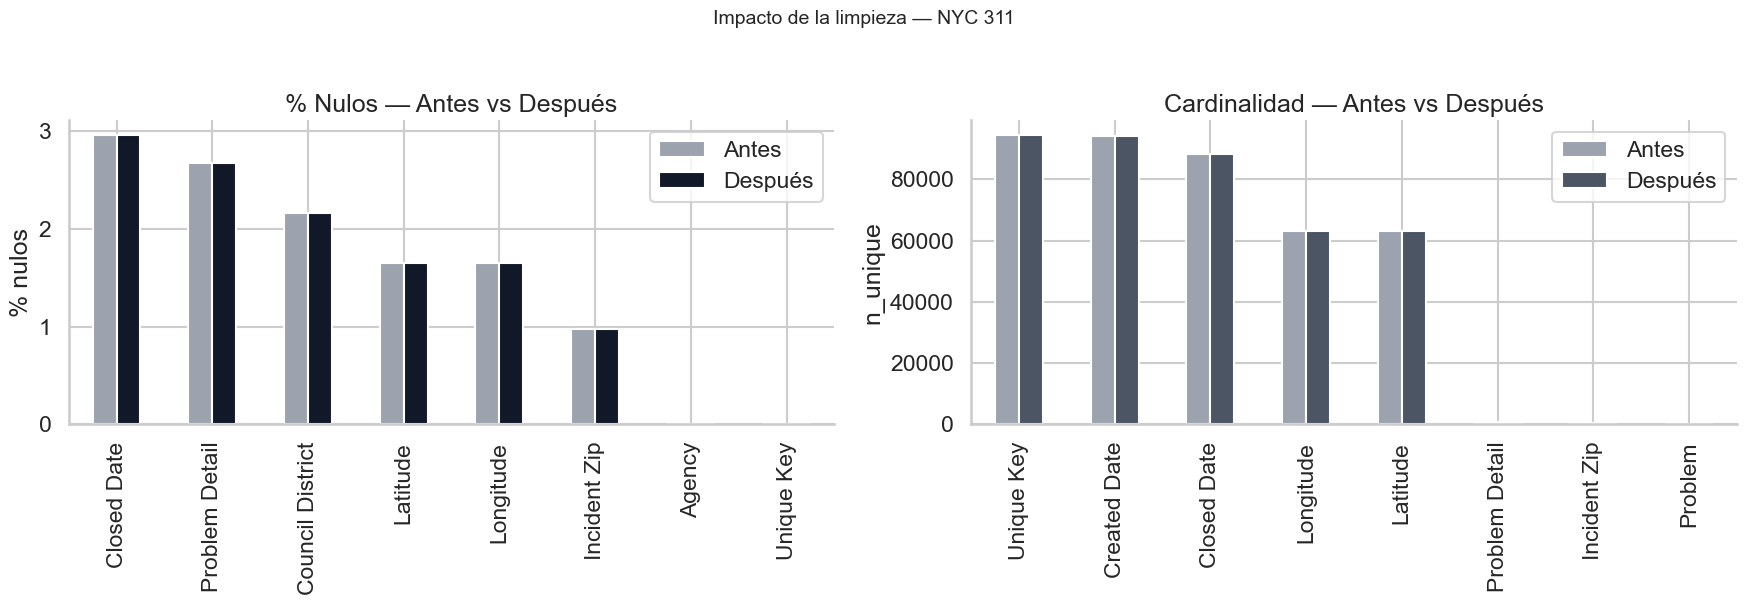

In [35]:
# Gráfico comparativo de nulos y cardinalidad
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

comparison.sort_values('missing_pct_before', ascending=False).head(8).plot(
    kind='bar',
    y=['missing_pct_before', 'missing_pct_after'],
    ax=axes[0],
    title='% Nulos — Antes vs Después',
    color=['#9ca3af', '#111827'],
    ylabel='% nulos',
)
axes[0].set_xlabel('')
axes[0].legend(['Antes', 'Después'])

comparison.sort_values('n_unique_before', ascending=False).head(8).plot(
    kind='bar',
    y=['n_unique_before', 'n_unique_after'],
    ax=axes[1],
    title='Cardinalidad — Antes vs Después',
    color=['#9ca3af', '#4b5563'],
    ylabel='n_unique',
)
axes[1].set_xlabel('')
axes[1].legend(['Antes', 'Después'])

plt.suptitle('Impacto de la limpieza — NYC 311', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cleaning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Bitácora de transformaciones

La limpieza no se considera completa hasta que puede explicarse. Esta bitácora documenta cada campo afectado, el problema observado, la regla aplicada y el impacto medido. Es el artefacto que permite reproducir y defender cada decisión.


In [36]:
cleaning_log_df = pd.DataFrame(cleaning_log)
cleaning_log_df

,field,problem,rule,impact
0,Created Date / Closed Date,dtype object — fechas sin parsear,"pd.to_datetime(errors=""coerce"") aplicado en ca...","Habilitado cálculo temporal; 2,801 fechas de c..."
1,Created Date → year / month / day_of_week / ho...,fecha en bruto — no usable directamente en Tab...,dt.year / dt.month / dt.day_name() / dt.hour /...,6 campos derivados; 0 registros fuera de rango...
2,resolution_hours / resolution_days,campo derivado no existe en raw; valores negat...,Closed Date - Created Date; negativos y > 5 añ...,37 negativos + 0 extremos invalidados
3,Borough,"""Unspecified"" como categoría inválida; mayúscu...","str.strip().str.title(); replace(""Unspecified""...",106 registros sin borough válido → NaN
4,Latitude / Longitude,dtype str; separador decimal con coma; coorden...,"str.replace("","", "".""); pd.to_numeric; bounding...","1,559 coordenadas inválidas → NaN; dtype ahora..."
5,Incident Zip,"dtype object; valores como ""11420.0""; ZIPs de ...","strip + remove "".0"" + extract 5 dígitos con regex",Cardinalidad reducida a 216 ZIPs válidos
6,Agency,posible variación de capitalización / espacios,str.strip().str.upper(),cardinalidad 16 → 16
7,Status,posible variación de capitalización / espacios,str.strip().str.upper(),cardinalidad 7 → 7
8,Open Data Channel Type,posible variación de capitalización / espacios,str.strip().str.upper(),cardinalidad 5 → 5
9,Unique Key (filas),posibles duplicados por carga por chunks,"drop_duplicates(subset=[""Unique Key""])",0 filas eliminadas


---
## 6. Verificación de integridad pre-exportación

Antes de exportar, confirmamos que el dataset limpio cumple las condiciones mínimas para conectarse a Tableau sin ambigüedades de tipo.


In [38]:
print('=== VERIFICACIÓN DE INTEGRIDAD ===')
print(f'\nShape final: {df.shape}')
print(f'Filas totales: {len(df):,}')
print(f'Columnas: {df.shape[1]}')

print('\nDtypes finales:')
print(df.dtypes)

print('\nNulos por columna (%):')
null_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print(null_pct[null_pct > 0])

# Checks críticos
assert df['Unique Key'].nunique() == len(df), 'ERROR: hay Unique Keys duplicados'
assert df['Created Date'].dtype == 'datetime64[us]', 'ERROR: Created Date no es datetime'
assert df['Latitude'].dtype == 'float64', 'ERROR: Latitude no es float64'
assert df['year'].astype(int).between(2020, 2026).all(), 'ERROR: hay años fuera del rango esperado'

print('\n✓ Todos los checks de integridad pasados')

=== VERIFICACIÓN DE INTEGRIDAD ===

Shape final: (94500, 23)
Filas totales: 94,500
Columnas: 23

Dtypes finales:
Unique Key                         int64
Created Date              datetime64[us]
Closed Date               datetime64[us]
Agency                          category
Problem                              str
Problem Detail                       str
Incident Zip                         str
Status                          category
Community Board                      str
Council District                 float64
Police Precinct                      str
Borough                         category
Open Data Channel Type          category
Latitude                         float64
Longitude                        float64
year                            category
month                           category
month_name                      category
day_of_week                     category
hour_of_day                     category
date                      datetime64[us]
resolution_hours          

---
## 7. Exportación

Exportamos tres archivos:
- `311_clean.csv` — dataset limpio completo, listo para conectar a Tableau
- `cleaning_log.csv` — bitácora de transformaciones
- `cleaning_comparison.csv` — tabla antes vs después para documentación del portafolio

Usamos `save_for_tableau` del módulo `_shared` del curso, que garantiza la ruta de output estructurada por semana.


In [39]:
# Para exportar a CSV con Tableau, convertimos category → str
df_export = df.copy()
for col in df_export.select_dtypes('category').columns:
    df_export[col] = df_export[col].astype(str).replace('nan', '')

path_clean      = save_for_tableau(df_export, WEEK, '311_clean')
path_log        = save_for_tableau(cleaning_log_df, WEEK, 'cleaning_log')
path_comparison = save_for_tableau(comparison.reset_index(), WEEK, 'cleaning_comparison')

print(f'✓ Dataset limpio exportado:  {path_clean}')
print(f'✓ Bitácora exportada:        {path_log}')
print(f'✓ Comparación exportada:     {path_comparison}')

✓ Dataset limpio exportado:  outputs\week-03-311\311_clean.csv
✓ Bitácora exportada:        outputs\week-03-311\cleaning_log.csv
✓ Comparación exportada:     outputs\week-03-311\cleaning_comparison.csv


---
## 8. Reflexión metodológica

### Decisiones de limpieza que pueden defenderse

| Problema | Alternativa descartada | Decisión tomada | Razón |
|---|---|---|---|
| Borough = 'Unspecified' | Mantenerlo como categoría | → NaN | 'Unspecified' no es un borough de NYC; incluirlo distorsionaría mapas |
| resolution_hours negativos | Tomar valor absoluto | → NaN | No hay base metodológica para asumir que el error solo está en el signo |
| Coordenadas fuera del bounding box | Imputar por borough | → NaN | La imputación geoespacial requiere un join externo que introduce supuestos no documentados |
| Problem tiene 272 valores únicos | Agrupar ahora | Se mantiene sin agrupar | La agrupación es una decisión analítica, no de limpieza; va en el notebook de modelado |

### Qué no se limpió (y por qué)

- **`Problem` y `Problem Detail`**: la reducción de cardinalidad (272 tipos) no es limpieza —es modelado analítico. Hacerlo aquí mezclaría etapas del pipeline.
- **`Closed Date` con 1.9% de nulos**: los registros abiertos o en progreso legítimamente no tienen fecha de cierre. Imputar sería inventar datos.
- **`Council District`**: tiene 2.3% de nulos pero es un campo de georreferencia secundario. Se mantiene sin imputar; el Borough ya cubre la dimensión geográfica principal.

### Lecciones del proceso

- `str.replace(',', '.')` en Latitude/Longitude resolvió un problema de localización regional (CSV exportado con configuración de idioma español)
- La separación entre _limpieza_ (este notebook) y _modelado analítico_ (siguiente notebook) permite defender cada decisión en su capa correcta del pipeline
- El uso de `_shared.py` del curso como referencia garantiza coherencia con los estándares metodológicos de la materia
